In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import calendar

In [48]:
all_files = glob.glob(r'C:\Users\user\OneDrive\Desktop\electronics-ecommerce-sales\data\raw-data\*.csv')
print("Files found:", len(all_files))

df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])
print("\nColumns:", df.columns.tolist())

Files found: 12
Total Rows: 186850
Total Columns: 6

Columns: ['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address']


In [49]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [50]:
# Check basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


In [51]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

Duplicate Rows: 1162


In [52]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [53]:
# Remove missing values
df.dropna(inplace=True)

In [ ]:
# Confirm cleaning
print("Remaining Rows:", df.shape[0])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Remaining Rows: 185686
Missing Values: 0
Duplicate Rows: 0


In [54]:
# Remove rows where Order ID is not a number
df = df[df['Order ID'].str.isnumeric() == True]

In [55]:
# Fix data types
df['Order ID'] = df['Order ID'].astype(int)
df['Quantity Ordered'] = df['Quantity Ordered'].astype(int)
df['Price Each'] = df['Price Each'].astype(float)
df['Order Date'] = pd.to_datetime(df['Order Date'])

C:\Users\user\AppData\Local\Temp\ipykernel_27076\1107044299.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


In [56]:
# Confirm data types
print(df.dtypes)

Order ID                     int64
Product                     object
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
dtype: object


In [ ]:
# Add Revenue column
df['Revenue'] = df['Quantity Ordered'] * df['Price Each']

In [ ]:
# Extract Month from Order Date
df['Month'] = df['Order Date'].dt.month_name()

In [ ]:
# Extract Hour from Order Date
df['Hour'] = df['Order Date'].dt.hour

In [ ]:
# Extract City from Purchase Address
df['City'] = df['Purchase Address'].apply(lambda x: x.split(',')[1].strip())

In [ ]:
# Check new columns
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Revenue,Month,Hour,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.90,April,8,Dallas
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",99.99,April,22,Boston
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",600.00,April,14,Los Angeles
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",11.99,April,14,Los Angeles
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",11.99,April,9,Los Angeles


In [ ]:
# Save Cleaned Data
df.to_csv(r'C:\Users\user\OneDrive\Desktop\electronics-ecommerce-sales\data\cleaned_data.csv', index=False)
print("cleaned_data.csv saved successfully!")

cleaned_data.csv saved successfully!


In [ ]:
# Total Revenue
total_revenue = df['Revenue'].sum()
print("Total Revenue: $", round(total_revenue, 2))

Total Revenue: $ 34465537.94


In [ ]:
# Monthly Revenue
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('Revenue', ascending=False)
print(monthly_revenue)

        Month     Revenue
2    December  4608295.70
10    October  3734777.86
0       April  3389217.98
9    November  3197875.05
8         May  3150616.23
7       March  2804973.35
5        July  2646461.32
6        June  2576280.15
1      August  2241083.37
3    February  2200078.08
11  September  2094465.69
4     January  1821413.16


In [ ]:
# Monthly Revenue Chart
import calendar

In [ ]:
# Sort by month order
month_order = list(calendar.month_name)[1:]
monthly_revenue['Month'] = pd.Categorical(monthly_revenue['Month'], categories=month_order, ordered=True)
monthly_revenue = monthly_revenue.sort_values('Month')

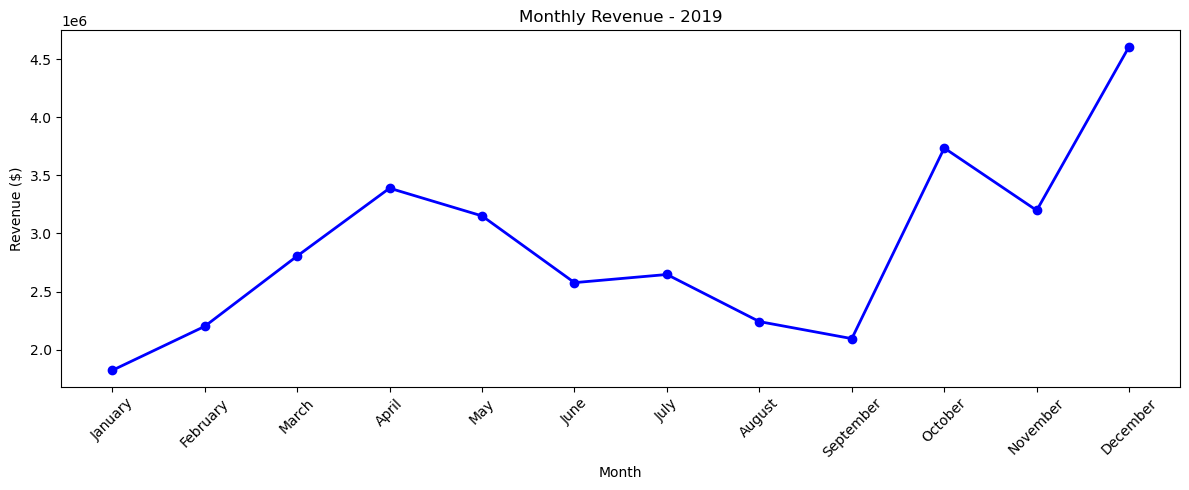

In [ ]:
# Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['Month'], monthly_revenue['Revenue'], marker='o', color='blue', linewidth=2)
plt.title('Monthly Revenue - 2019')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 Products by Revenue
top_products = df.groupby('Product')['Revenue'].sum().reset_index()
top_products = top_products.sort_values('Revenue', ascending=False).head(10)

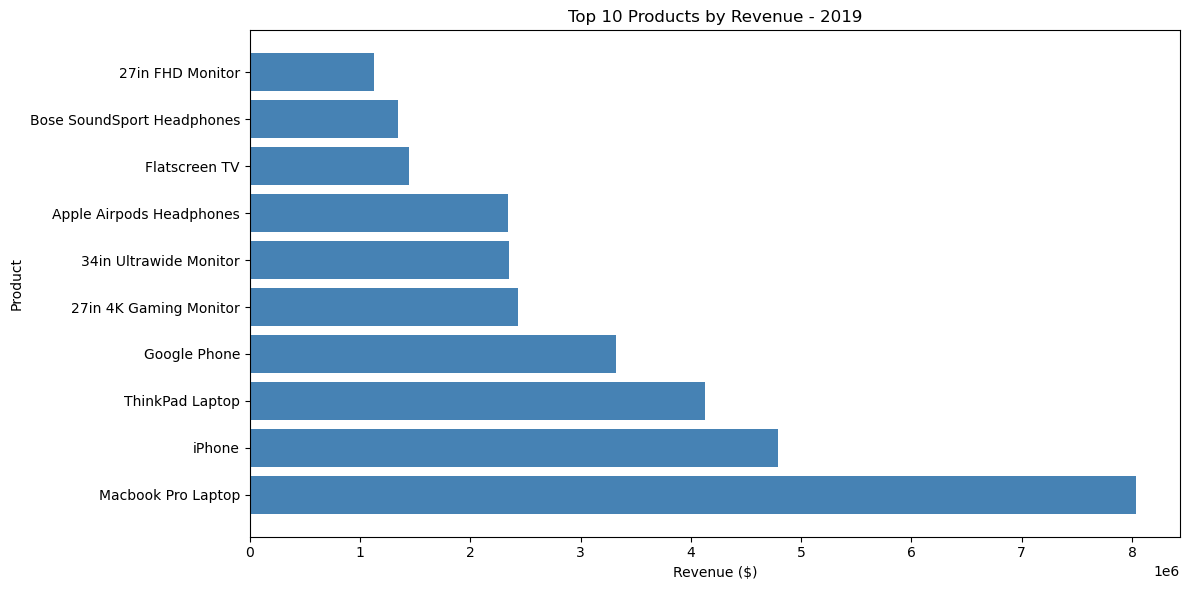

In [ ]:
# Plot
plt.figure(figsize=(12, 6))
plt.barh(top_products['Product'], top_products['Revenue'], color='steelblue')
plt.title('Top 10 Products by Revenue - 2019')
plt.xlabel('Revenue ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [ ]:
# Revenue by City
city_revenue = df.groupby('City')['Revenue'].sum().reset_index()
city_revenue = city_revenue.sort_values('Revenue', ascending=False)

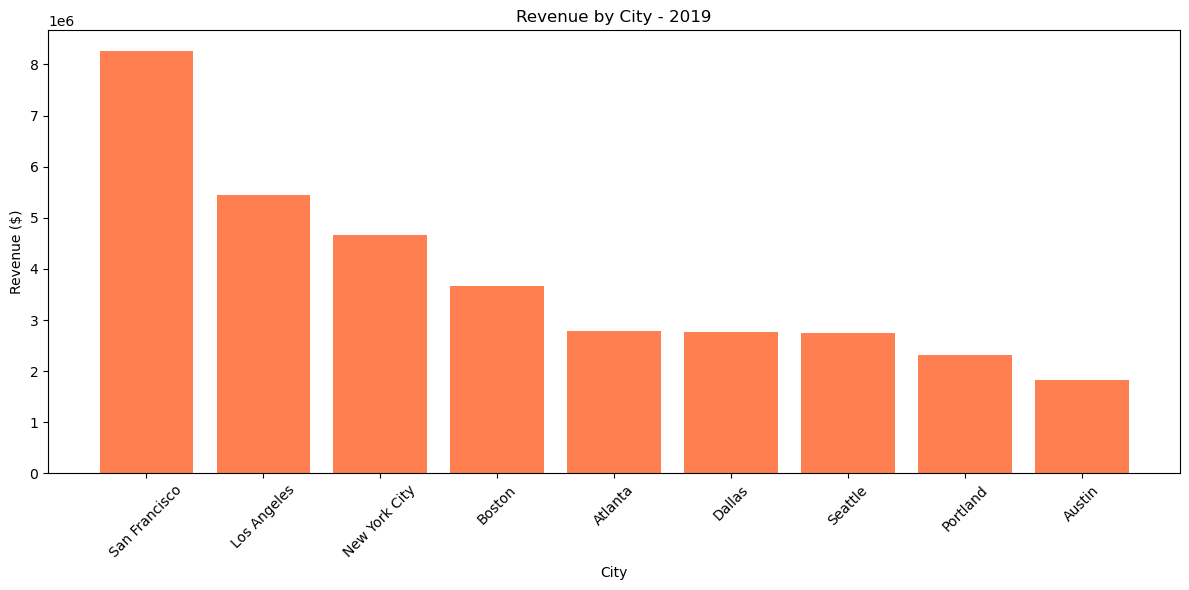

In [ ]:
# Plot
plt.figure(figsize=(12, 6))
plt.bar(city_revenue['City'], city_revenue['Revenue'], color='coral')
plt.title('Revenue by City - 2019')
plt.xlabel('City')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Orders by Hour
hourly_orders = df.groupby('Hour')['Order ID'].count().reset_index()
hourly_orders.columns = ['Hour', 'Orders']

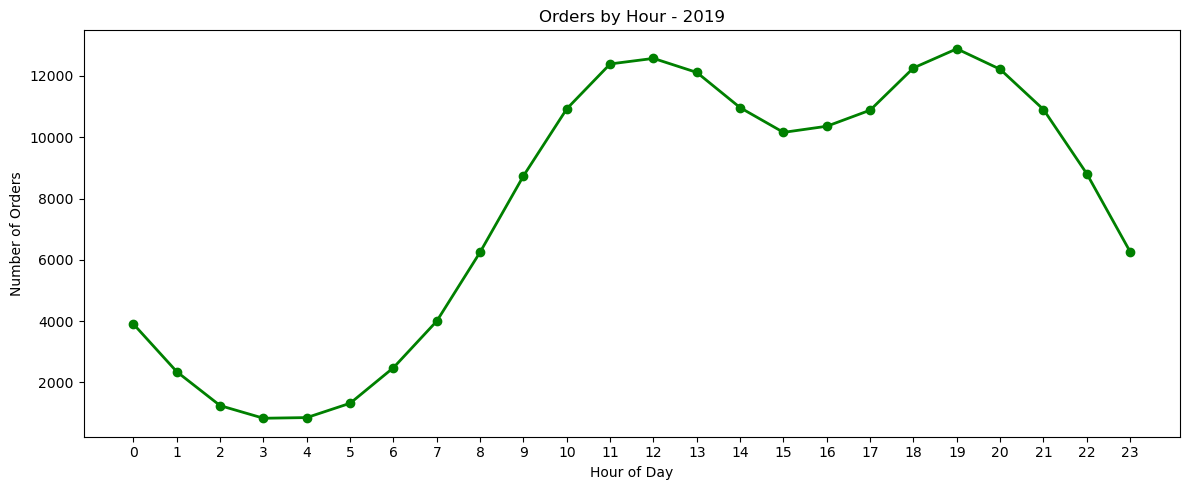

In [ ]:
# Plot
plt.figure(figsize=(12, 5))
plt.plot(hourly_orders['Hour'], hourly_orders['Orders'], marker='o', color='green', linewidth=2)
plt.title('Orders by Hour - 2019')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 Products by Quantity Sold
top_quantity = df.groupby('Product')['Quantity Ordered'].sum().reset_index()
top_quantity = top_quantity.sort_values('Quantity Ordered', ascending=False).head(10)

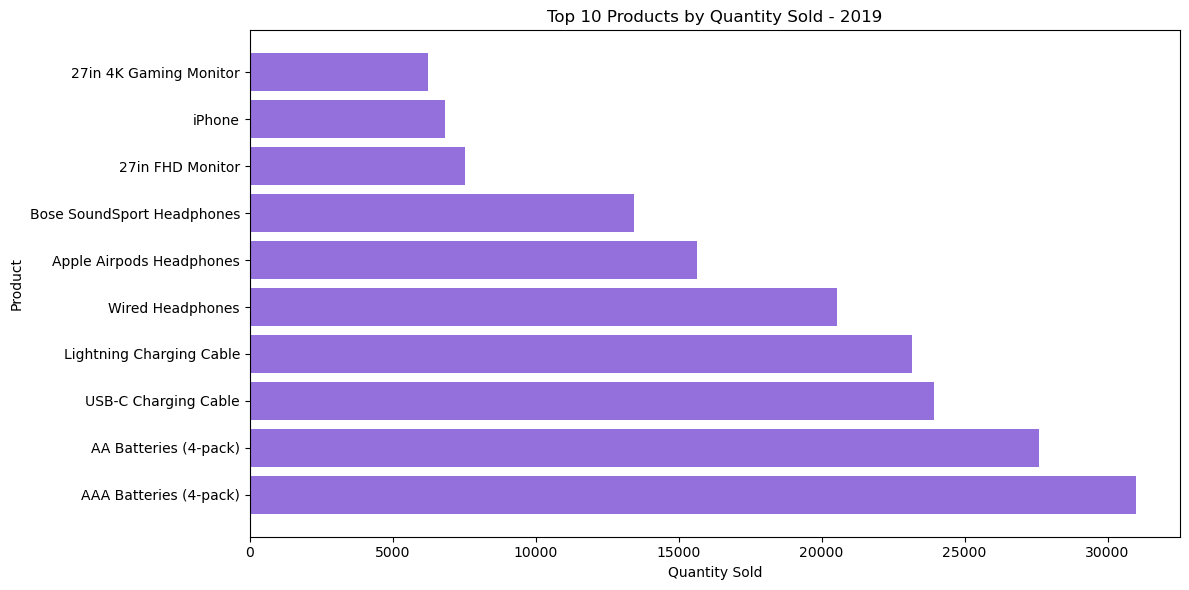

In [ ]:
# Plot
plt.figure(figsize=(12, 6))
plt.barh(top_quantity['Product'], top_quantity['Quantity Ordered'], color='mediumpurple')
plt.title('Top 10 Products by Quantity Sold - 2019')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [ ]:
# Revenue by Product (Quantity vs Revenue comparison)
product_summary = df.groupby('Product').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Quantity Ordered', 'sum')
).reset_index().sort_values('Total_Revenue', ascending=False)

print(product_summary)

                       Product  Total_Revenue  Total_Quantity
13          Macbook Pro Laptop     8032500.00            4725
18                      iPhone     4792900.00            6847
14             ThinkPad Laptop     4127958.72            4128
9                 Google Phone     3317400.00            5529
1       27in 4K Gaming Monitor     2433147.61            6239
3       34in Ultrawide Monitor     2352898.08            6192
6     Apple Airpods Headphones     2345550.00           15637
8                Flatscreen TV     1443900.00            4813
7   Bose SoundSport Headphones     1342865.70           13430
2             27in FHD Monitor     1131074.59            7541
16             Vareebadd Phone      827200.00            2068
0                 20in Monitor      453818.74            4126
11          LG Washing Machine      399600.00             666
10                    LG Dryer      387600.00             646
12    Lightning Charging Cable      346376.55           23169
15      